# Coweeta ELM+ATS Coupled Workflow

This workflow generates all input files needed for a coupled ELM+ATS simulation at the
Coweeta watershed. ELM drives all meteorological forcing and provides porosity (watsat)
to ATS at runtime via the ELM-ATS coupling layer.

Datasets used:
* `NHD Plus HR` for hydrography
* `3DEP` for elevation
* `NLCD` for land cover (PFT assignment for ELM)
* `NRCS/SSURGO` for soil texture (sand/clay → ELM pedotransfer → watsat; Rosetta → ATS WRM)

Outputs written to `elm_output_data/`:
* `coweeta.exo` — 3D mesh (15 layers, ~42 m deep, Oak Harbor dz structure)
* `coweeta.h5` — lat/lon cell data for ELM column matching
* `coweeta_domain.nc` — ELM domain file
* `coweeta_surfdata.nc` — ELM surface data (PFT, texture, geometry)
* `coweeta.xml` — ATS input file (based on oakharbor_transect.xml)
* `coweeta_subsurface_properties.csv` — soil properties lookup table

After running this notebook, copy the outputs into `examples/coweeta/` and
`inputdata/lnd/clm2/surfdata_map/` as described in the completion cell.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
## FIX ME -- why is this broken without importing netcdf first?
import netCDF4

In [3]:
import watershed_workflow.io
watershed_workflow.io.setupLogging(1)

In [4]:
import os, sys
import logging
import numpy as np
from matplotlib import pyplot as plt
import shapely
import pandas as pd
import geopandas as gpd
pd.options.display.max_columns = None

# ats_input_spec is not pip-installable; add its source tree to the path
sys.path.insert(0, os.path.expanduser('~/code/ats/ats_input_spec/repos/master'))

import watershed_workflow
import watershed_workflow.utils
import watershed_workflow.sources
import watershed_workflow.plot
import watershed_workflow.mesh
import watershed_workflow.properties.land_cover
import watershed_workflow.hydro
import watershed_workflow.io
import watershed_workflow.io.elm
import watershed_workflow.sources.standard_names as names

import ats_input_spec
import ats_input_spec.public
import ats_input_spec.io

import amanzi_xml.utils.io as aio
import amanzi_xml.utils.search as asearch
import amanzi_xml.utils.errors as aerrors

plt.rcParams['figure.figsize'] = (8, 6)

## Parameters

In [5]:
# -----------------------------------------------------------------------
# Paths
# -----------------------------------------------------------------------
def splitPathFull(path):
    parts = []
    while True:
        head, tail = os.path.split(path)
        if head == path:
            parts.insert(0, head); break
        elif tail == path:
            parts.insert(0, tail); break
        else:
            parts.insert(0, tail); path = head
    return parts

cwd = splitPathFull(os.getcwd())
if cwd[-1] == 'Coweeta':
    pass
elif cwd[-1] == 'examples':
    cwd.append('Coweeta')
else:
    cwd.extend(['examples', 'Coweeta'])

data_dir = os.path.join(*(cwd + ['input_data']))
def toInput(f): return os.path.join(data_dir, f)

output_dir = os.path.join(*(cwd + ['elm_output_data']))
os.makedirs(output_dir, exist_ok=True)
def toOutput(f): return os.path.join(output_dir, f)

work_dir = os.path.join(*cwd)
def toWorkingDir(f): return os.path.join(work_dir, f)

# Point at local data cache so this notebook works offline / without large downloads
watershed_workflow.utils.setDataDirectory(data_dir)

# -----------------------------------------------------------------------
# Mesh / watershed parameters
# -----------------------------------------------------------------------
name = 'coweeta'
coweeta_shapefile = toInput('coweeta_basin.shp')

simplify          = 60
ignore_small_rivers = 2
prune_by_area_fraction = 0.01

refine_L0 = 125;  refine_L1 = 300
refine_d0 = 200;  refine_d1 = 600
refine_A0 = refine_L0**2 / 2
refine_A1 = refine_L1**2 / 2

# -----------------------------------------------------------------------
# ELM / ATS template paths
# -----------------------------------------------------------------------
# Oak Harbor 1-column surfdata used as template for SurfdataBuilder
template_surfdata = toInput('elm_ats_surfdata_template.nc')

# ATS XML template (site-independent ELM-ATS skeleton with MESH_FILENAME placeholders)
ats_xml_template = toInput('elm_ats_template.xml')

met_bypass_dir = '$DIN_LOC_ROOT/atm/datm7/atm_forcing.datm7.AORC/cpl_bypass_full'

print(f'template_surfdata: {template_surfdata}')
print(f'ats_xml_template : {ats_xml_template}')
print(f'output_dir       : {output_dir}')

template_surfdata: /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/input_data/elm_ats_surfdata_template.nc
ats_xml_template : /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/input_data/elm_ats_template.xml
output_dir       : /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data


In [6]:
output_filenames = {}

In [7]:
crs = watershed_workflow.crs.default_crs

## Section 1: Basin Geometry

2026-05-26 09:15:24,968 - root - INFO: fixing column: geometry
2026-05-26 09:15:24,973 - root - INFO: Removing holes on 1 polygons
2026-05-26 09:15:24,973 - root - INFO:   -- removed interior
2026-05-26 09:15:24,973 - root - INFO:   -- union
2026-05-26 09:15:24,974 - root - INFO: Parsing 1 components for holes
2026-05-26 09:15:24,974 - root - INFO:   -- complete


<Axes: >

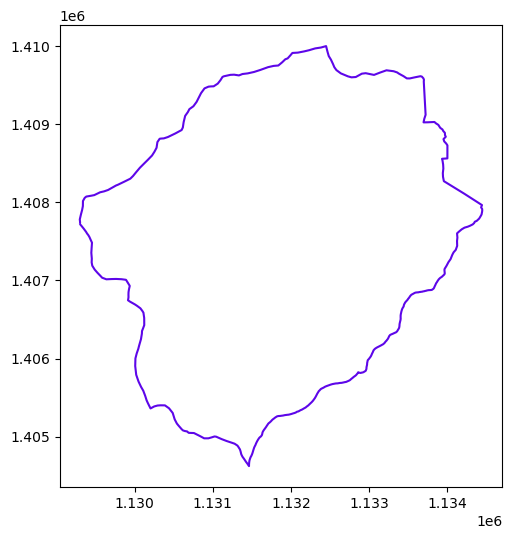

In [8]:
coweeta_source = watershed_workflow.sources.ManagerShapefile(coweeta_shapefile)
coweeta = coweeta_source.getShapes(out_crs=crs)
coweeta.rename(columns={'AREA': names.AREA}, inplace=True)
watershed = watershed_workflow.Watershed(coweeta)
watershed.plot()

In [9]:
sources = watershed_workflow.sources.getDefaultSources()
sources['hydrography'] = watershed_workflow.sources.sources['geometry']['NHDPlusHR-pynhd_nhdplushr']
watershed_workflow.sources.logSources(sources)

2026-05-26 09:15:25,051 - root - INFO: Using sources:
2026-05-26 09:15:25,052 - root - INFO: --------------
2026-05-26 09:15:25,052 - root - INFO: HUC: ManagerWBD
2026-05-26 09:15:25,052 - root - INFO: hydrography: ManagerNHD
2026-05-26 09:15:25,052 - root - INFO: DEM: Manager3DEP
2026-05-26 09:15:25,052 - root - INFO: soil structure: ManagerNRCS
2026-05-26 09:15:25,053 - root - INFO: geologic structure: ManagerGLHYMPS
2026-05-26 09:15:25,053 - root - INFO: depth to bedrock: ManagerPelletierDTB
2026-05-26 09:15:25,053 - root - INFO: land cover: ManagerNLCD
2026-05-26 09:15:25,053 - root - INFO: LAI: ManagerMODISEarthdata
2026-05-26 09:15:25,054 - root - INFO: meteorology: ManagerAORC
2026-05-26 09:15:25,054 - root - INFO: evapotranspiration: ManagerSSEBop
2026-05-26 09:15:25,054 - root - INFO: observations: ManagerNWIS


In [10]:
reaches = sources['hydrography'].getShapesByGeometry(watershed.exterior, crs, out_crs=crs)
rivers  = watershed_workflow.hydro.createRivers(reaches, method='hydroseq')
watershed_orig, rivers_orig = watershed, rivers

2026-05-26 09:15:25,077 - root - INFO:   Shapes manager: buffered+snapped query box = (-83.482, 35.024, -83.418, 35.077)
2026-05-26 09:15:25,163 - root - INFO: fixing column: geometry
2026-05-26 09:15:25,183 - root - INFO: fixing column: catchment


In [11]:
def createCopy(ws, rivs):
    return ws.deepcopy(), [r.deepcopy() for r in rivs]

watershed, rivers = createCopy(watershed_orig, rivers_orig)

watershed_workflow.simplify(watershed, rivers, refine_L0, refine_L1, refine_d0, refine_d1)
for river in rivers:
    river.resetDataFrame()
for river in rivers:
    watershed_workflow.hydro.findOutletsByCrossings(watershed, river)

2026-05-26 09:15:25,212 - root - INFO: 
2026-05-26 09:15:25,212 - root - INFO: Simplifying
2026-05-26 09:15:25,213 - root - INFO: ------------------------------
2026-05-26 09:15:25,213 - root - INFO: EPSG:5070
2026-05-26 09:15:25,213 - root - INFO: Presimplify to remove colinear, coincident points.
2026-05-26 09:15:25,215 - root - INFO: EPSG:5070
2026-05-26 09:15:25,215 - root - INFO: Pruning leaf reaches < 125
2026-05-26 09:15:25,215 - root - INFO: EPSG:5070
2026-05-26 09:15:25,216 - root - INFO: Merging internal reaches < 125
2026-05-26 09:15:25,216 - root - INFO: EPSG:5070
2026-05-26 09:15:25,218 - root - INFO:   reach: min seg length: 	    4.7213180357 	min geom length: 	  165.1231825930
2026-05-26 09:15:25,218 - root - INFO:   reach: med seg length: 	    5.7469025712 	med geom length: 	  987.4061283577
2026-05-26 09:15:25,218 - root - INFO:   reach: max seg length: 	   28.5938776314 	max geom length: 	 4068.7144554581
2026-05-26 09:15:25,218 - root - INFO: 
2026-05-26 09:15:25,219

2026-05-26 09:15:25,396 - root - INFO: 
2026-05-26 09:15:25,396 - root - INFO: Stream-aligned Meshing
2026-05-26 09:15:25,396 - root - INFO: ------------------------------
2026-05-26 09:15:25,396 - root - INFO: Creating stream-aligned mesh...
2026-05-26 09:15:25,428 - root - INFO:  ... created a mesh with 190 elements for river 0
2026-05-26 09:15:25,428 - root - INFO: Adjusting HUC to match reaches at outlet
2026-05-26 09:15:25,436 - root - INFO:   is nonoverlapping?  total_area = 205801.2474072762, summed_area = 205801.2474072762
2026-05-26 09:15:25,436 - root - INFO: Building the remaining triangular mesh...
2026-05-26 09:15:25,436 - root - INFO: 
2026-05-26 09:15:25,436 - root - INFO: Triangulation
2026-05-26 09:15:25,437 - root - INFO: ------------------------------
2026-05-26 09:15:25,449 - root - INFO: Triangulating...
2026-05-26 09:15:25,450 - root - INFO:    455 points and 456 facets
2026-05-26 09:15:25,450 - root - INFO:  checking graph consistency
2026-05-26 09:15:25,450 - ro

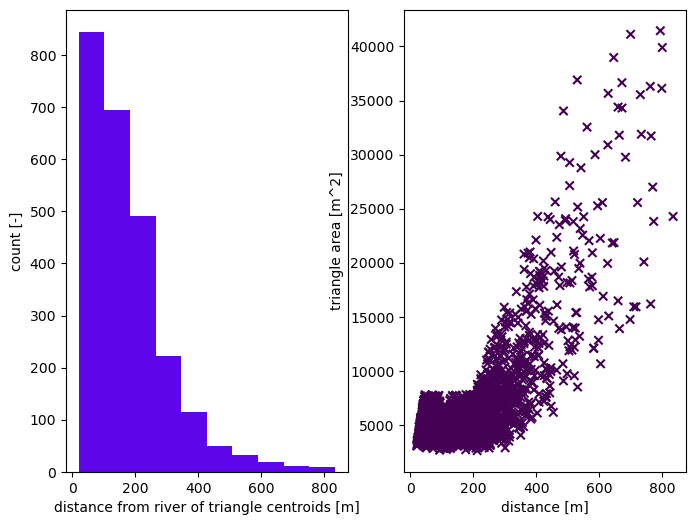

In [12]:
min_angle = 32

def widths(reach):
    mapping = {1: 8, 2: 12, 3: 16}
    return mapping.get(reach.properties['stream_order'], 8)

m2, areas, dists = watershed_workflow.tessalateRiverAligned(
    watershed, rivers,
    river_width=widths,
    refine_min_angle=min_angle,
    refine_distance=[refine_d0, refine_A0, refine_d1, refine_A1],
    diagnostics=True)

In [13]:
# elevate to a dem
dem = sources['DEM'].getDataset(watershed.exterior.buffer(100), watershed.crs)['dem']
watershed_workflow.elevate(m2, dem)

2026-05-26 09:15:31,844 - root - INFO: Incoming shape area = 0.001768840316859954
2026-05-26 09:15:31,844 - root - INFO: ... buffering incoming shape by 3x native resolution = 0.00324
2026-05-26 09:15:31,845 - root - INFO: ... buffered shape area = 0.0023523275716883477
2026-05-26 09:15:31,845 - root - INFO: Manager3DEP: cache hit at /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/input_data/elevation/3DEP_60m/py3dep_tnm/py3dep_tnm_-83.4829_35.0233_-83.4170_35.0784


In [14]:
# now deal with the river...
# adding elevations to the river tree for stream bed conditioning
watershed_workflow.mesh.setProfileByDEM(rivers, dem)

In [15]:
# now condition the river to fix places where the DEM does not intersect the river
def computeBurnInDepthFromData(reach):
    return reach['bankfull_depth'] 

def computeBurnInDepth(da_sq_miles):
    """burn-in depth as a function of drainage area"""
    depth_in_feet = 1.22 * da_sq_miles**0.317
    return 0.3048 * depth_in_feet # ft --> meters

def computeBurnInDepthFromDA(reach):
    depth = computeBurnInDepth(reach['drainage_area_sqkm'] * 0.386102)
    logging.debug(f"reach of DA {reach['drainage_area_sqkm']} has depth {depth}")
    return depth

watershed_workflow.mesh.conditionRiverMeshes(m2,
                       rivers,
                       network_burn_in_depth=computeBurnInDepthFromDA)

In [16]:
# hydrologically condition the mesh, removing pits
outlet_edge = watershed_workflow.mesh.Edge(rivers[0]['elems'][-1][0],rivers[0]['elems'][-1][-1])
print(outlet_edge)
river_cells = [i for (i,elem) in enumerate(m2.conn) if len(elem) > 3]    
m2, res = watershed_workflow.mesh.conditionMesh(m2, preserved_pits=river_cells, forced_outlet_edges=[outlet_edge,])

2026-05-26 09:15:32,025 - root - INFO: 
2026-05-26 09:15:32,025 - root - INFO: Running marching_iterative: 6 initial pits
2026-05-26 09:15:32,025 - root - INFO: ==============================================================================
2026-05-26 09:15:32,178 - root - INFO:  ... iteration 0 of marching: 1 pits


Edge(0, 380)


2026-05-26 09:15:32,328 - root - INFO:  ... iteration 1 of marching: 1 pits
2026-05-26 09:15:32,478 - root - INFO:  ... iteration 2 of marching: 1 pits
2026-05-26 09:15:32,478 - root - INFO:  ... done iterating, max iterations.
2026-05-26 09:15:32,511 - root - INFO:   completed: 1 final pits, 5 removed
2026-05-26 09:15:32,511 - root - INFO:     - 1 'internal' pits with max depth 5.436848958333485 and median 5.436848958333485
2026-05-26 09:15:32,511 - root - INFO:   RMSE of dz: 0.10463231238752121
2026-05-26 09:15:32,512 - root - INFO:   MAE of dz: 0.0045790376772588326
2026-05-26 09:15:32,512 - root - INFO:   MAX of dz: 3.13311767578125
2026-05-26 09:15:32,512 - root - INFO: Refining 1 triangles -- topology will change!
2026-05-26 09:15:32,560 - root - INFO: 
2026-05-26 09:15:32,560 - root - INFO: Running marching_iterative: 1 initial pits
2026-05-26 09:15:32,560 - root - INFO: ==============================================================================
2026-05-26 09:15:32,713 - root

In [17]:
print(m2.cell_areas[0])

5573.98080026525


In [18]:
# pre-partition
m2 = m2.partition(4, True)

In [19]:
print(m2.cell_areas[0])
print(m2.centroids[0])

4029.9606990153047
[1.13250097e+06 1.40887104e+06 7.49100952e+02]


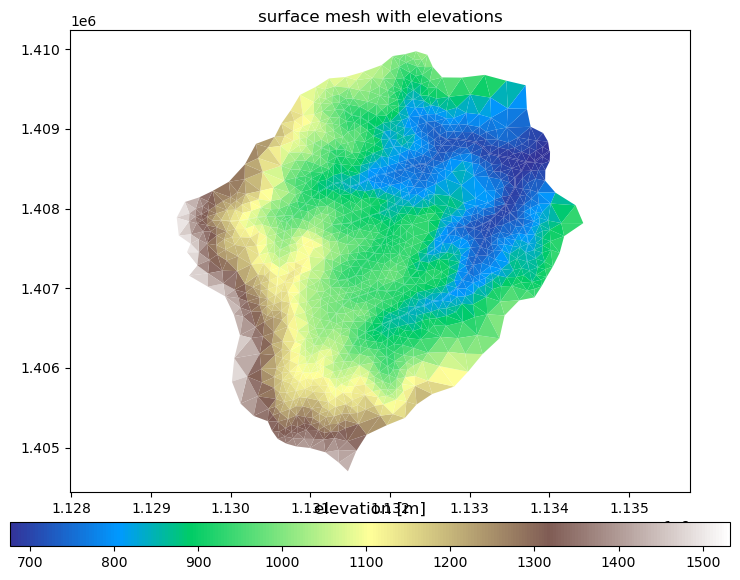

In [20]:
fig, ax = plt.subplots()
cbax = fig.add_axes([0.05, 0.02, 0.9, 0.04])
mp = m2.plot(facecolors='elevation', edgecolors=None, ax=ax, colorbar=False)
fig.colorbar(mp, orientation='horizontal', cax=cbax).ax.set_title('elevation [m]')
ax.set_title('surface mesh with elevations')
ax.set_aspect('equal', 'datalim')
plt.show()

In [21]:
watershed_workflow.mesh.addWatershedAndOutletRegions(m2, watershed, outlet_width=250, exterior_outlet=True)
watershed_workflow.mesh.addRiverCorridorRegions(m2, rivers)
watershed_workflow.mesh.addStreamOrderRegions(m2, rivers)

for ls in m2.labeled_sets:
    print(f'{ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

2026-05-26 09:15:33,106 - root - INFO: Adding regions for 1 polygons
2026-05-26 09:15:33,125 - root - INFO: Exterior outlet point (from attribute): POINT (1134002.8976153187 1408719.2929211305)


10000 : CELL : 2701 : "0"
10001 : CELL : 2701 : "0 surface"
10002 : FACE : 76 : "0 boundary"
10003 : FACE : 5 : "0 outlet"
10004 : FACE : 5 : "surface domain outlet"
10005 : CELL : 190 : "river corridor 0 surface"
10006 : CELL : 16 : "stream order 3"
10007 : CELL : 48 : "stream order 2"
10008 : CELL : 126 : "stream order 1"


In [22]:
print(m2.num_cells)

2701


## Section 2: NLCD Land Cover and ELM PFT Assignment

In [23]:
nlcd = sources['land cover'].getDataset(watershed.exterior.buffer(100), watershed.crs)['cover']
logging.info('Found land cover types: {}'.format(set(list(nlcd.values.ravel()))))

2026-05-26 09:15:33,180 - root - INFO: Incoming shape area = 0.001768840316859954
2026-05-26 09:15:33,181 - root - INFO: ... buffering incoming shape by 3x native resolution = 0.00081
2026-05-26 09:15:33,181 - root - INFO: ... buffered shape area = 0.001909149726363946
2026-05-26 09:15:33,181 - root - INFO: ManagerNLCD: cache hit at /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/input_data/land_cover/NLCD_L48_2021/pygeohydro_mrlc/pygeohydro_mrlc_-83.4800_35.0263_-83.4200_35.0754
2026-05-26 09:15:33,189 - root - INFO: Found land cover types: {np.int16(71), np.int16(41), np.int16(42), np.int16(43), np.int16(81), np.int16(52), np.int16(21), np.int16(22), np.int16(23), np.int16(-1)}


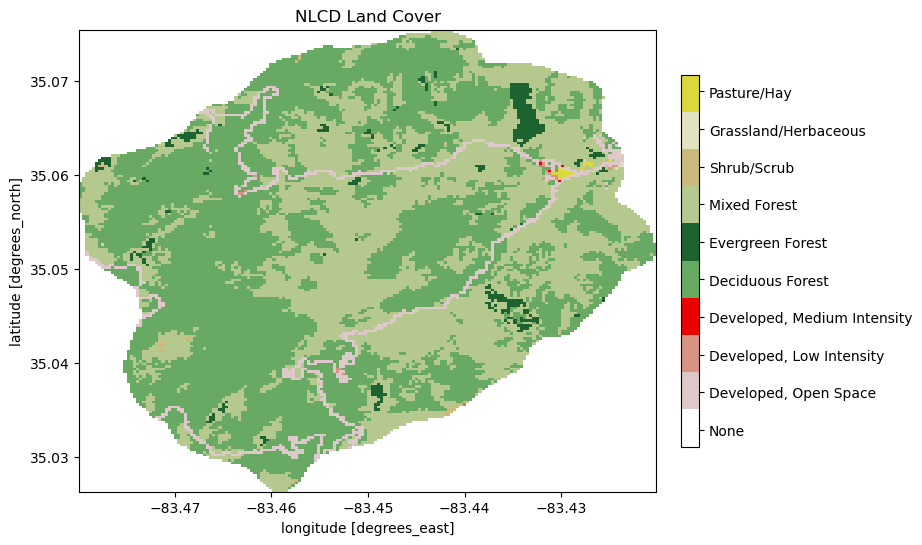

In [24]:
nlcd_indices, nlcd_cmap, nlcd_norm, nlcd_ticks, nlcd_labels = \
    watershed_workflow.plot.createNLCDColormap(np.unique(nlcd))

fig, ax = plt.subplots()
nlcd.plot.imshow(ax=ax, cmap=nlcd_cmap, norm=nlcd_norm, add_colorbar=False)
watershed_workflow.plot.createIndexedColorbar(
    ncolors=len(nlcd_indices), cmap=nlcd_cmap, labels=nlcd_labels, ax=ax)
ax.set_title('NLCD Land Cover')
plt.show()

In [25]:
m2_nlcd = watershed_workflow.getDatasetOnMesh(m2, nlcd, method='nearest')
m2.cell_data['land_cover'] = m2_nlcd

assert 127 not in m2_nlcd, 'nodata NLCD value found on mesh'

nlcd_indices, nlcd_cmap, nlcd_norm, nlcd_ticks, nlcd_labels = \
    watershed_workflow.plot.createNLCDColormap(np.unique(m2_nlcd))

In [26]:
# Map NLCD codes to ELM natural PFT indices (0-16)
pft_index = watershed_workflow.properties.land_cover.mapNLCDToPFT(
    m2_nlcd, climate_zone='temperate')
m2.cell_data['pft index'] = pft_index

print('PFT indices on mesh:', np.unique(pft_index))

PFT indices on mesh: [ 1  7 13]


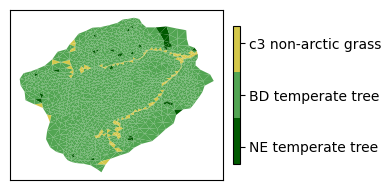

In [39]:
fig, ax = plt.subplots(1,1, figsize=(4,2))
pft_index_list, pft_cmap, pft_norm, pft_ticks, pft_labels = \
    watershed_workflow.plot.createPFTColormap(np.unique(pft_index))

mp = m2.plot('pft index', cmap=pft_cmap, norm=pft_norm,
             edgecolors=None, colorbar=False, ax=ax)
watershed_workflow.plot.createIndexedColorbar(
    ncolors=len(pft_index_list), cmap=pft_cmap, labels=pft_labels, ax=plt.gca())
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()

fig.savefig('./Coweeta_PFTs.png', dpi=300)

plt.show()

In [ ]:
nlcd_labels_dict = dict(zip(nlcd_indices, nlcd_labels))
watershed_workflow.mesh.addSurfaceRegions(m2, names=nlcd_labels_dict)

for ls in m2.labeled_sets:
    print(f'{ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

## Section 3: NRCS Soil Texture and ATS WRM Parameters

NRCS SSURGO provides sand/clay texture used for:
- ELM: pedotransfer function `watsat = 0.489 - 0.00126*sand` (all 15 nlevgrnd layers)
- ATS: Rosetta van Genuchten parameters (alpha, n, residual saturation) and permeability

Each column is vertically homogeneous — the same NRCS MUKEY texture applies to all 15
layers.  ELM internally duplicates layer-10 texture for layers 11-15 (SoilStateType.F90
lines 708-713), consistent with this approach.

In [ ]:
nrcs = sources['soil structure'].getShapesByGeometry(
    watershed.exterior, watershed.crs, out_crs=crs)
nrcs

In [ ]:
print(watershed_workflow.properties.soil.__file__)

In [ ]:
def replace_column_nans(df, col_nan, col_replacement):
    mask = df[col_nan].isna()
    df.loc[mask, col_nan] = df.loc[mask, col_replacement]

# Fill any missing Rosetta-derived values with Rosetta fallback columns
replace_column_nans(nrcs, 'porosity [-]', 'Rosetta porosity [-]')
replace_column_nans(nrcs, 'permeability [m^2]', 'Rosetta permeability [m^2]')

# Drop Rosetta backup columns (we keep the originals, now gap-filled)
for col in ['Rosetta porosity [-]', 'Rosetta permeability [m^2]',
            'bulk density [g/cm^3]']:
    if col in nrcs.columns:
        nrcs.pop(col)

# Drop any rows still containing NaN
nan_mask = nrcs.isna().any(axis=1)
dropped = nrcs.index[nan_mask]
if len(dropped):
    logging.warning(f'Dropping {len(dropped)} NRCS rows with NaN after gap-fill: {list(dropped)}')
nrcs = nrcs[~nan_mask]

nrcs

In [ ]:
# Map NRCS MUKEY onto the 2D mesh cells
soil_color_mukey = watershed_workflow.getShapePropertiesOnMesh(
    m2, nrcs, 'mukey', resolution=50, nodata=-999)

# Fail if any mesh cell has no NRCS coverage
assert -999 not in soil_color_mukey, \
    'Some mesh cells have no NRCS coverage (nodata=-999). Check watershed extent vs SSURGO.'

nrcs.set_index('mukey', drop=False, inplace=True)

unique_mukeys = list(np.unique(soil_color_mukey))
nrcs = nrcs.loc[unique_mukeys]  # keep only MUKEYs that appear on the mesh

# Assign sequential ATS IDs starting at 1000
nrcs['ATS ID'] = range(1000, 1000 + len(unique_mukeys))
nrcs.set_index('ATS ID', drop=True, inplace=True)

# Build the ATS-ID indexed soil color array
soil_color = -np.ones_like(soil_color_mukey)
for ats_id, mukey in zip(nrcs.index, nrcs['mukey']):
    soil_color[soil_color_mukey == mukey] = ats_id

m2.cell_data['soil_color'] = soil_color
print(f'{len(nrcs)} unique NRCS soil types on mesh, ATS IDs {nrcs.index.min()}–{nrcs.index.max()}')

In [ ]:
sc_indices, sc_cmap, sc_norm, sc_ticks, sc_labels = \
    watershed_workflow.plot.createIndexedColormap(nrcs.index)

mp = m2.plot(facecolors=m2.cell_data['soil_color'], cmap=sc_cmap, norm=sc_norm,
             edgecolors=None, colorbar=False)
watershed_workflow.plot.createIndexedColorbar(
    ncolors=len(nrcs), cmap=sc_cmap, labels=sc_labels, ax=plt.gca())
plt.title('NRCS Soil Type (ATS ID)')
plt.show()

In [ ]:
# Save subsurface properties CSV
output_filenames['subsurface_properties'] = toOutput(f'{name}_subsurface_properties.csv')
nrcs.to_csv(output_filenames['subsurface_properties'])
print('Saved:', output_filenames['subsurface_properties'])
nrcs

## Section 4: Extrude 2D Mesh to 3D

Uses ELM's default exponential 15-layer vertical grid (`elm_default_dzsoi`, ~42 m total depth).
All 15 layers get the same NRCS soil type as the surface cell (vertically homogeneous).
Mat IDs 1000–(1000+N) for ELM nlevsoi layers; same IDs continue for layers 11-15 since
ELM duplicates layer-10 texture internally.

In [ ]:
# ELM vertical grid -- uses ELM's default exponential formula (initVerticalMod.F90)
dzs = watershed_workflow.io.elm.elm_default_dzsoi(nlevgrnd=15)

print(f'Number of layers: {len(dzs)}')
print(f'Layer thicknesses: {np.round(dzs, 4)}')
print(f'Total depth: {dzs.sum():.2f} m')


In [ ]:
ncells = m2.num_cells
soil_color_arr = m2.cell_data['soil_color'].values  # shape (ncells,), ATS IDs

# All 15 layers get the surface cell's NRCS ATS ID (vertically homogeneous)
layer_mat_ids = [soil_color_arr.copy() for _ in range(15)]

watershed_workflow.Mesh3D.summarizeExtrusion(
    ['constant'] * 15, dzs.tolist(), [1] * 15, layer_mat_ids)

In [ ]:
m3 = watershed_workflow.Mesh3D.extruded_Mesh2D(
    m2, 'constant', dzs.tolist(), [1] * 15, layer_mat_ids)

In [ ]:
print('2D labeled sets')
for ls in m2.labeled_sets:
    print(f'  {ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

print('\n3D labeled sets')
for ls in m3.labeled_sets:
    print(f'  {ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

print('\n3D side sets')
for ss in m3.side_sets:
    print(f'  {ss.setid} : FACE : {len(ss.cell_list)} : "{ss.name}"')

In [ ]:
# Partition the 2D mesh and write lat/lon cell data for ELM column matching
import watershed_workflow.crs

centroids = m2.centroids[:, 0:2]
import watershed_workflow.utils.warp
lon, lat = watershed_workflow.utils.warp.warpXY(
    centroids[:, 0], centroids[:, 1], m2.crs, watershed_workflow.crs.latlon_crs)

m2.cell_data['longitude'] = lon
m2.cell_data['latitude']  = lat

output_filenames['mesh_h5'] = toOutput(f'{name}.h5')

# should put this capability somewhere in the library, but its specific to both ATS and HDF?
import h5py
with h5py.File(output_filenames['mesh_h5'], 'w') as fid:
    grp1 = fid.create_group('longitude.cell.0')
    grp1.create_dataset('0', data=lon)

    grp2 = fid.create_group('latitude.cell.0')
    grp2.create_dataset('0', data=lat)

print('Wrote:', output_filenames['mesh_h5'])

In [ ]:
# Write 3D mesh exodus file
output_filenames['mesh'] = toOutput(f'{name}.exo')
try:
    os.remove(output_filenames['mesh'])
except FileNotFoundError:
    pass
m3.writeExodus(output_filenames['mesh'], 'one block')
print('Wrote:', output_filenames['mesh'])

## Section 5: ELM Domain and Surface Data Files

- `writeDomain()` writes the ELM domain NetCDF (lat/lon/area/mask/frac per cell)
- `SurfdataBuilder` clones the Oak Harbor template surfdata, replaces geometry and land
  cover, then fills soil texture from NRCS sand/clay for the 10 ELM `nlevsoi` layers.
  ELM internally duplicates layer-10 texture for layers 11-15 (SoilStateType.F90 708-713).

In [ ]:
output_filenames['elm_domain'] = toOutput(f'{name}_domain.nc')
watershed_workflow.io.elm.writeDomain(m2, output_filenames['elm_domain'])
print('Wrote ELM domain:', output_filenames['elm_domain'])

In [ ]:
# Build the SurfdataBuilder (requires 'pft index' in m2.cell_data)
builder = watershed_workflow.io.elm.SurfdataBuilder(m2, template_surfdata)
nlevsoi = builder._nlevsoi  # should be 10
print(f'Template nlevsoi: {nlevsoi}')

In [ ]:
# Build soil_type array: shape (nlevsoi=10, ncells)
# All 10 layers get the surface cell's NRCS ATS ID
soil_type = np.tile(soil_color_arr, (nlevsoi, 1))  # (10, ncells)

# soil_properties DataFrame indexed by ATS ID
# setSoilProperties needs 'total sand pct [%]' and 'total clay pct [%]'
soil_props_for_elm = nrcs[['total sand pct [%]', 'total clay pct [%]']].copy()
if 'total gravel pct [%]' in nrcs.columns:
    soil_props_for_elm['total gravel pct [%]'] = nrcs['total gravel pct [%]']

builder.setSoilProperties(soil_type, soil_props_for_elm)
print('Set soil properties for', nlevsoi, 'layers x', ncells, 'cells')

In [ ]:
output_filenames['elm_surfdata'] = toOutput(f'{name}_surfdata.nc')
builder.write(output_filenames['elm_surfdata'])
print('Wrote ELM surfdata:', output_filenames['elm_surfdata'])

## Section 6: Write user_nl_elm

Writes `user_nl_elm` to `elm_output_data/` using AORC cpl_bypass met forcing
(`metdata_type = 'atssubdaily'`). The AORC zone files cover 2010–2022 at 1-hour
resolution; `zone_mappings.txt` maps every Coweeta cell to zone 19.

After the notebook completes, copy `elm_output_data/user_nl_elm` to
`examples/coweeta/` alongside the other case files before running
`examples/coweeta/build_example.sh`.


In [ ]:
user_nl_elm_content = f"""&dynamic_subgrid
 do_harvest = .false.
 do_transient_pfts = .false.
 flanduse_timeseries = ''

&finidat_consistency_checks
 check_finidat_fsurdat_consistency = .false.
 check_finidat_year_consistency = .false.

&clm_inparm
 do_budgets = .true.
 use_nofire = .true.
 metdata_type = 'atssubdaily'
 metdata_bypass = '{met_bypass_dir}'

 aero_file = '$DIN_LOC_ROOT/atm/cam/chem/trop_mozart_aero/aero/aerosoldep_monthly_1850_mean_1.9x2.5_c090421.nc'
 CO2_file = '$DIN_LOC_ROOT/atm/datm7/CO2/fco2_datm_1765-2007_c100614.nc'

 nyears_ad_carbon_only = 25
 spinup_mortality_factor = 10

 stream_fldfilename_popdens = '$DIN_LOC_ROOT/lnd/clm2/firedata/clmforc.Li_2012_hdm_0.5x0.5_AVHRR_simyr1850-2010_c130401.nc'
 stream_fldfilename_ndep = '$DIN_LOC_ROOT/lnd/clm2/ndepdata/fndep_elm_cbgc_exp_simyr1849-2101_1.9x2.5_c190103.nc'

"""

# Write to elm_output_data/ alongside other outputs
user_nl_elm_path = toOutput('user_nl_elm')
with open(user_nl_elm_path, 'w') as f:
    f.write(user_nl_elm_content)

output_filenames['user_nl_elm'] = user_nl_elm_path
print('Wrote:', user_nl_elm_path)

## Section 7: Write ATS Input XML

Loads `oakharbor_transect.xml` as a template and injects:
1. Mesh filename (coweeta.exo / coweeta.h5)
2. Labeled set regions from m3
3. Per-soil-type WRM parameters (van Genuchten alpha/n/Sr, permeability) from NRCS/Rosetta

Porosity is **not** set here — ELM computes watsat from texture and passes it to ATS at
runtime via ExternalModelATS.F90.  The `compressible porosity` evaluator in the template
XML uses ELM's `base_porosity` directly.

In [ ]:
# Relative paths from the ATS run directory to the mesh files
# The run directory will be examples/coweeta/ and the mesh is in elm_output_data/
rel_exo = os.path.join('elm_output_data', f'{name}.exo')
rel_h5  = os.path.join('elm_output_data', f'{name}.h5')

print('Mesh exo (relative to run dir):', rel_exo)
print('Mesh h5  (relative to run dir):', rel_h5)

In [ ]:
# Load the template XML and replace the MESH_FILENAME placeholders via string substitution
with open(ats_xml_template, 'r') as f:
    xml_str = f.read()

xml_str = xml_str.replace('MESH_FILENAME.exo', rel_exo)
xml_str = xml_str.replace('MESH_FILENAME.h5',  rel_h5)

xml = aio.fromString(xml_str)
print('Loaded template and updated mesh filename references.')

In [ ]:
# Build new region / WRM / permeability entries via ats_input_spec,
# then convert to XML and splice into the loaded template.
#
# We build a scratch main_props list we never write directly — just use it to
# generate well-formed XML sublists that we splice into the template xml.

main_props = ats_input_spec.public.get_main()

# Regions: add all labeled sets from the extruded 3D mesh.
# add_soil_type (below) will also add per-soil-type regions, so between the two
# calls we cover everything.  The template's fixed-named regions ('computational
# domain', 'surface domain', 'bottom', 'surface', 'surface outlet', soil layers)
# will be replaced or kept by the splice logic in the next cell.
for ls in m3.labeled_sets:
    ats_input_spec.public.add_region_labeled_set(
        main_props, ls.name, ls.setid, rel_exo, ls.entity)
for ss in m3.side_sets:
    ats_input_spec.public.add_region_labeled_set(
        main_props, ss.name, ss.setid, rel_exo, 'FACE')

# WRM + permeability (no porosity — ELM provides base_porosity at runtime)
for ats_id in nrcs.index:
    props = nrcs.loc[ats_id]
    region_name = f'soil type {ats_id}'
    smoothing = 0.01 if props['van Genuchten n [-]'] < 1.5 else 0.0

    ats_input_spec.public.add_soil_type(
        main_props, region_name, label=ats_id, filename=rel_exo,
        porosity=None,                              # ELM provides base_porosity
        permeability=float(props['permeability [m^2]']),
        van_genuchten_alpha=float(props['van Genuchten alpha [Pa^-1]']),
        van_genuchten_n=float(props['van Genuchten n [-]']),
        residual_sat=float(props['residual saturation [-]']),
        smoothing_interval=float(smoothing),
    )

main_xml = ats_input_spec.io.to_xml(main_props)
print(f'Built region + WRM + permeability entries for {len(nrcs)} soil types.')

In [ ]:
# Splice main_xml subtrees into the loaded template xml

# Regions: add/replace each new region into the template's region list
xml_regions = asearch.find_path(xml, ['regions'], no_skip=True)
for new_region in asearch.find_path(main_xml, ['regions'], no_skip=True):
    rname = new_region.getName()
    try:
        xml_regions.replace(rname, new_region)
    except aerrors.MissingXMLError:
        xml_regions.append(new_region)

# WRM parameters: replace single 'all layers' placeholder with per-soil entries
xml_mp = asearch.find_path(xml, ['state', 'model parameters'], no_skip=True)
new_wrm = asearch.find_path(main_xml, ['state', 'model parameters', 'WRM parameters'],
                             no_skip=True)
try:
    xml_mp.replace('WRM parameters', new_wrm)
except aerrors.MissingXMLError:
    xml_mp.append(new_wrm)

# Permeability evaluator: replace placeholder with per-soil-type tensor evaluator
xml_ev = asearch.find_path(xml, ['state', 'evaluators'], no_skip=True)
new_perm = asearch.find_path(main_xml, ['state', 'evaluators', 'permeability'],
                              no_skip=True)
try:
    xml_ev.replace('permeability', new_perm)
except aerrors.MissingXMLError:
    xml_ev.append(new_perm)

print('Spliced regions, WRM parameters, and permeability into template XML.')

In [ ]:
# Write the final ATS XML
output_filenames['ats_xml'] = toOutput(f'{name}.xml')
aio.toFile(xml, output_filenames['ats_xml'])
print('Wrote ATS XML:', output_filenames['ats_xml'])

## Summary and Next Steps

After this notebook completes, copy output files to their final destinations:

```bash
# From watershed_workflow/examples/Coweeta/

# ATS mesh and XML -> examples/shared/
cp elm_output_data/coweeta.exo  ../../../examples/shared/
cp elm_output_data/coweeta.h5   ../../../examples/shared/
cp elm_output_data/coweeta.xml  ../../../examples/shared/

# ELM surfdata and domain -> inputdata
cp elm_output_data/coweeta_surfdata.nc \
   ../../../E3SM/inputdata/lnd/clm2/surfdata_map/
cp elm_output_data/coweeta_domain.nc \
   ../../../E3SM/inputdata/lnd/clm2/surfdata_map/

# ELM case files -> examples/coweeta/
cp elm_output_data/user_nl_elm ../../../examples/coweeta/
```

Then build and run the ELM+ATS coupled simulation:

```bash
cd ../../../examples/coweeta
./build_example.sh
```


In [ ]:
print(f'{"role":<35}: filename')
print('-' * 36 + ': ' + '-' * 50)
for k, v in output_filenames.items():
    print(f'{k:<35}: {v}')